In [1]:
# Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt


## Exercise 1.4

In [2]:
def g(x):
    g = np.exp(-x**2)
    return g

In [3]:
def fd(h):
    g_prime = (g(1+h) - g(1)) / h
    return np.round(g_prime,4)

def bd(h):
    g_prime = (g(1) - g(1-h)) / h
    return np.round(g_prime,4)

def cd(h):
    g_prime = (g(1+h) - g(1-h)) / (2*h)
    return np.round(g_prime,4)

In [4]:
h_array = np.array([0.1, 0.01, 0.001])

In [5]:
for h in h_array:
    # print(fd(h))
    # print(bd(h))
    print(cd(h))

-0.7333
-0.7357
-0.7358


In [6]:
print('actual value is ', -2 / np.e)

actual value is  -0.7357588823428847


## Exercise 1.11
Implement trapezoid rule to estimate the area under the Gaussian curve defined by $g(x) = e^{-x^2}$ ( ```g(x)``` function)

\begin{equation}
    A = \sum_{i=0}^{N-1} \frac{(x_{i+1} - x_i)(g(x_{i+1}) + g(x_i))}{2}
\end{equation}

In [7]:
def test(x):
    output = 1+x
    return output

def call_test(f, x):
    output = f(x)
    return output

In [8]:
call_test(test,np.arange(0,3))

array([1, 2, 3])

In [9]:
def trapzx_tails(f, L, x_length = 200, state=True):
    """
    Parameters:
        f is the function defining the integrand
        L is the distance from 0 that we will use to calculate the integral. for x > L, the integral is approximately 0
        dx is the spacing of x-values (width of trapezoid)
    
    Returns:
        A: Approximate area under the curve calculated using trapezoids (-L,L)
        A_tail: Approximate area under the curve calculated using trapezoids (sum of (-inf, L] U (L, +inf))
        error: Z = pi - A
    """
    # define an x-array
    x = np.linspace(-L,L,x_length)

    # calculate dx 
    dx = np.abs(x[1] - x[0])
    
    # calculate f(x)
    f_array = f(x)
    
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_f = (f_array[:-1] + f_array[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    A = (dx * avg_f).sum()

    # calculate the area under the curve for the tail
    x_tail = np.linspace(L, 10**16, x_length)
    dx = np.abs(x_tail[1] - x_tail[0])
    f_array_tail = f(x_tail)
    avg_f_tail = (f_array_tail[:-1] + f_array_tail[1:]) / 2
    A_tail = (dx * avg_f_tail).sum() * 2 # x2 b/c there are two tails
    

    # compare to the true value of Z = sqrt(pi)
    Z = np.sqrt(np.pi)

    error_minusLtoL = Z - A 
    
    if np.abs(error_minusLtoL < 10**(-16)):
        if state==True:
            print(f'For dx={"%.2e" % dx} and L={L}, the integral of g(x) from -L to L = sqrt(\u03C0)')
        
    return A, A_tail, error_minusLtoL

In [10]:
def trapzx(f, L, x_length = 200, state=True):
    """
    Parameters:
        f is the function defining the integrand
        L is the distance from 0 that we will use to calculate the integral. for x > L, the integral is approximately 0
        dx is the spacing of x-values (width of trapezoid)
    
    Returns:
        A: Approximate area under the curve calculated using trapezoids (-L,L)
        A_tail: Approximate area under the curve calculated using trapezoids (sum of (-inf, L] U (L, +inf))
        error: Z = pi - A
    """
    # define an x-array
    x = np.linspace(-L,L,x_length)

    # calculate dx 
    dx = np.abs(x[1] - x[0])
    
    # calculate f(x)
    f_array = f(x)
    
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_f = (f_array[:-1] + f_array[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    A = (dx * avg_f).sum()

    print(f'Z = ','%.2e' % A)
        
    return A

In [11]:
A, A_tail, error_minusLtoL = trapzx_tails(g,10,200)

For dx=5.03e+13 and L=10, the integral of g(x) from -L to L = sqrt(π)


### doesn't this also depend on your choice of ``dx``?

## Exercise 1.13a

Write code to calculate the **error function** to calculate the $errf(x)$ for any real $x$ found using the trapezoid function written in Excercise 1.11.

\begin{equation}
    erf(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-t^2} \, \text{d}t
\end{equation}

*I assume there is a time dependence (t) because x can change over time? Like if the Gaussian is advected to the right?*

In [12]:
def erf(x_bound, state=True):
    A, A_tail, error_minusLtoL = trapzx_tails(g, x_bound, state=False)
    erf = 2/np.sqrt(np.pi) * (A/2) # divide A by 2 since trapzx uses from [-L,L] instead of [0,L] for integral limits
    if state==True:
        print(f'P(error \u2208 (-{x_bound},{x_bound})) =', '%.2e'% erf)
    return erf

In [13]:
erf(0.8)

P(error ∈ (-0.8,0.8)) = 7.42e-01


np.float64(0.7420958363211435)

## Exercise 1.13b
Write code to calculate the inverse error function. Given $erf(x) = y \text{ s.t. } y \in(-1,1)$, what is $x$?

If the error function is the integral of $g(x) = e^{-t^2}$ for limits $x=0, x=L$, then we can take the trapezoid function for increasing values of $x$ until we get an integral equal to the value of $y$?

In [14]:
def inv_erf(y, tol=10**(-1)):
    x_bound = 0
    calculated_erf = 10

    # calculate the area under the g(x) curve for increasing upper bounds of x
    while np.abs(calculated_erf - y) > tol:
        x_bound += 0.1
        calculated_erf = erf(x_bound,False)
        

    print(f'if erf(x)= {y}, then x = {'%.2e' % x_bound}')
       
    return x_bound, calculated_erf, y

In [15]:
inv_erf(0.95)

if erf(x)= 0.95, then x = 1.10e+00


(1.0999999999999999, np.float64(0.8801975301112309), 0.95)

## Exercise 1.15a

Let 
\begin{equation}
    f(x;\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
\end{equation}

be a **normal probability density function**
>- Note that previously, the function g(x) was the non-normalized PDF where $\mu =0,\, \sigma = \frac{1}{\sqrt(2)}, A = 1$.

Evaluate 
\begin{equation}
    P(a; \mu, \sigma) = \int_{\mu - a}^{\mu + a} f(x; \mu, \sigma) \, \text{d}x
\end{equation}

In [16]:
# define f(x; mu, sigma)
def f(x, mu, sigma):
    f = (1/np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x-mu)**2/(2*sigma**2))
    return f

# modify trapezoid function to make bounds [mu-a, mu+a] instead of [-L,L]
def P(a, mu, sigma, x_length = 200):
    # define the limits of integration
    upper_bound = mu + a
    lower_bound = mu - a
    
    # define an x-array
    x = np.linspace(lower_bound,upper_bound,x_length)
    

    # calculate dx 
    dx = np.abs(x[1] - x[0])
    
    # calculate f(x)
    f_array = f(x, mu, sigma)
    
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_f = (f_array[:-1] + f_array[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    A = (dx * avg_f).sum()
        
    return A

## Exercise 1.15b & c

Given a fraction $p \in (0,1)$, write a function that uses ``inv_erf`` to find the value of $a$ where
\begin{equation}
    P(a;, \mu, \sigma) = p.
\end{equation}

In [17]:
def inv_P(p, mu, sigma, tol=10**(-5)):
    a_boundL = 0
    a_boundU = 20 # start from a super large upper bound
    a_bound = (a_boundL + a_boundU) / 2
    calculated_P = 10

    # calculate the area under the P(x,mu,sigma) curve using a binary search
    while np.abs(a_boundU - a_boundL) > tol:
        a_bound = (a_boundL + a_boundU) / 2
        calculated_P = P(a_bound, mu, sigma)

        if calculated_P - p > 0: # calculated_P is greater than p
            # make the region smaller by making the new upper bound the a_bound (midpoint)
            a_boundU = a_bound
        else: # calculated_P is less than p
            # make the region larger by making the new lower bound the a_bound (midpoint)
            a_boundL = a_bound
                
    print(f'if P(x)= {p}, then a = {'%.2e' % a_bound}')
    return a_bound, calculated_P, p

### Exercise 1.15d
Test your code (``inv_P``) for $p=0.68$ and $p=0.95$ when $\mu = 0$ and $\sigma = 1$.

In [18]:
a_bound_68, calculated_P_68, p_68 = inv_P(0.68,0,1)

if P(x)= 0.68, then a = 9.94e-01


In [19]:
a_bound_95, calculated_P_95, p_95 =inv_P(0.95,0,1)

if P(x)= 0.95, then a = 1.96e+00


<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pr/xbk_8gxd23x12v_jy009m_sw0000gn/T/ipykernel_18738/4143226103.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('$P(x=a; \mu=0, \sigma=1)$')


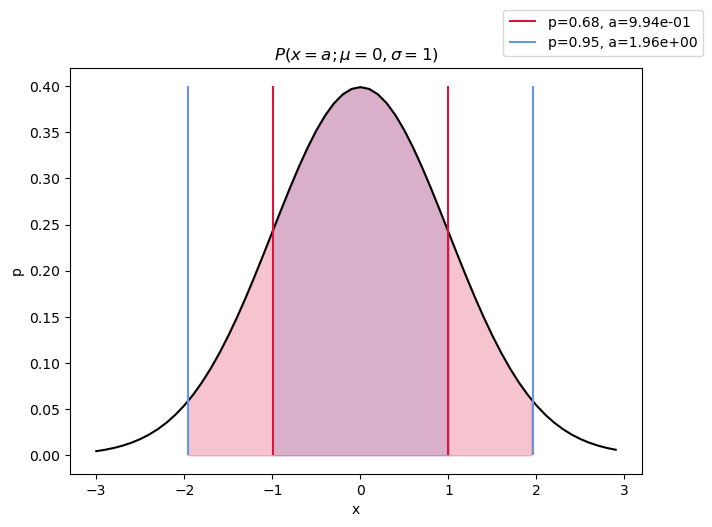

In [20]:
# check work with plot
x_array = np.arange(-3,3,0.1)
p_array = f(x_array, 0, 1)

fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ax.plot(x_array,p_array,color='black')
ax.vlines(-a_bound_68,0,0.4,color='crimson',label=f'p=0.68, a={'%.2e' % a_bound_68}')
ax.vlines(a_bound_68,0,0.4,color='crimson')

ax.vlines(-a_bound_95,0,0.4,color='cornflowerblue',label=f'p=0.95, a={'%.2e' % a_bound_95}')
ax.vlines(a_bound_95,0,0.4,color='cornflowerblue')


# create arrays for fill_between
a_bound_68_array = np.arange(-a_bound_68, a_bound_68+0.1, 0.1)
a_bound_68_p_array = f(a_bound_68_array, 0, 1)

a_bound_95_array = np.arange(-a_bound_95, a_bound_95, 0.1)
a_bound_95_p_array = f(a_bound_95_array, 0, 1)

ax.fill_between(a_bound_68_array, a_bound_68_p_array,0,alpha=0.25,color='cornflowerblue')
ax.fill_between(a_bound_95_array, a_bound_95_p_array,0,alpha=0.25,color='crimson')

ax.set_title('$P(x=a; \mu=0, \sigma=1)$')
ax.set_ylabel('p')
ax.set_xlabel('x')
fig.legend(bbox_to_anchor=(1.1,1.08))

## Exercise 1.16c

Determine the value of $Z$ needed to normalize the following function where $\beta > 0$.
\begin{equation}
    f(x) = \frac{1}{Z \left[ \beta^2 + (x-\alpha)^2\right]}
\end{equation}

Integrate $f(x)$ from $-\infty$ to $\infty$, and let $f(x) =1$

\begin{equation}
    Z = \int_\infty^\infty \frac{1}{[\beta^2 + (x-\alpha)^2]} \, \text{d}x
\end{equation}

In [21]:
def c(x, beta, alpha):
    if beta > 0:
        c = (beta**2 + (x - alpha)**2)**(-1)
    else:
        print('beta must be positive')
        c = np.array([])
    
    return c

In [22]:
trapzx(lambda x: c(x, 1, 0.5), 200, x_length=1000)

Z =  3.13e+00


np.float64(3.1315926601900386)

## Exercise 1.16f
Determine the value of $Z$ needed to normalize the following function.
\begin{equation}
    f(x) = \frac{1}{Z} \frac{1}{(1+x^2)^2}
\end{equation}

Integrate $f(x)$ from $-\infty$ to $\infty$, and let $f(x) =1$
\begin{equation}
    Z = \int_{-\infty}^\infty (1+x^2)^{-2} \, \text{d}x
\end{equation}

In [23]:
def f16(x):
    f16 = (1+x**2)**(-2)
    return f16

In [24]:
trapzx(lambda x: f16(x), 200, x_length=1000)

Z =  1.57e+00


np.float64(1.5707882155097388)

## Exercise 1.17 
Use the ```trapzx``` function to evaluate the mean and variance of a normal distribution numerically where $p(x)$ is a normal distribution. 

\begin{align}
    \mathbf{expectation} &= \mathbb{E}[f(x)] \int_{\Omega} f(x) p(x) \, \text{d}x \\
    \mathbf{mean} &= \mathbb{E}[x] = \int_{\Omega} x p(x) \, \text{d}x \\
    \mathbf{variance} &= \mathbb{E}[(x-\mathbb{E}[x])^2] = \int_{\Omega} (x - \mathbb{E}[x])^2 p(x) \, \text{d}x
\end{align}

Recall the the normal distribution is defined as follows
\begin{equation}
    p = \frac{1}{\sqrt(2 \pi \sigma^2)} e^{-\frac{(x-\mu)^2}{2 \sigma^2}}
\end{equation}

In [212]:
def normal_dist(a, mu, sigma, x_length =1000):
    # define the range over which you want to define the normal distribution
    upper_bound = mu + a
    lower_bound = mu - a
    
    # define an x-array
    x = np.linspace(lower_bound,upper_bound,x_length)
    
    p_array = (1/np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x-mu)**2 / (2* sigma**2))
    
    return p_array, x

In [213]:
def E(x, p, dx):
    """
    Parameters:
        x is the array of x-values used to calculate p(x) 
        p is the array of probability values (1 for each x-value of x) 
    """
    # calculate p
    # p, x = normal_dist(a, mu, sigma)
    
    # calculate the integrand
    integrand = x * p

    # calculate dx
    # dx = np.abs(x[1] - x[0])

    # integrate using the trapezoid sum
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_integrand = (integrand[:-1] + integrand[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    E = (dx * avg_integrand).sum()

    return E

In [214]:
a = 100
mu = 2
sigma = 3
p, x= normal_dist(a, mu, sigma,x_length=1000)
dx = np.abs(x[1] - x[0])

print(f'E[x] = {np.int32(E(x,p, dx))}')
print(f'E[x^2] = {np.int32(E(x**2, p, dx))}')
print(f'E[x-\u00B5] = {np.int32(E(x-mu,p, dx))}')
print(f'E[(x-\u00B5)^2] = {np.int32(E((x-mu)**2, p, dx))}')
print(f'E(x-\u00B5)^3] = {np.int32(E((x-mu)**3, p, dx))}')

E[x] = 2
E[x^2] = 13
E[x-µ] = 0
E[(x-µ)^2] = 9
E(x-µ)^3] = 0


## Exercise 1.22 
For the density 
\begin{equation}
    p(x) = \frac{1}{\pi \left( 1+x^2 \right)},
\end{equation}

compute $\mathbb{E}[x^n]$ numerically for $n= 0, 1, 2$. 
### a.
Approximate the integrals over the finite interval $x \in[-L,L]$ for several increasing values of $L$.

In [260]:
def p_dist_1_22(L, x_length = 1*10**5):
    """
    Parameters:
        L is the distance from 0 over which p is defined s.t. p(x) \\in [-L,L]
    """
    # define x-values
    x = np.linspace(-L,L,x_length)

    # define p(x)
    p = 1/(np.pi * (1+x**2))

    return p, x

In [261]:
# define a function that calculates E[x^n]
def E_xn(n,L):
    # calculate p over the interval [-L,L]
    p, x = p_dist_1_22(L)
    dx = np.abs(x[1] - x[0])

    # calculate E[x^n] for p \\in [-L,L]
    E_xn = E(x**n, p, dx)

    print(f'E[x^{n}] = {'%.4e' % E_xn} for L = {L}')

In [265]:
for n in range(0,3):
    print(f'n={n}')
    for L in np.array([1, 10, 100, 1000, 10000]):
        E_xn(n,L)
    print('_' * 10)

n=0
E[x^0] = 5.0000e-01 for L = 1
E[x^0] = 9.3655e-01 for L = 10
E[x^0] = 9.9363e-01 for L = 100
E[x^0] = 9.9936e-01 for L = 1000
E[x^0] = 9.9994e-01 for L = 10000
__________
n=1
E[x^1] = -1.3878e-17 for L = 1
E[x^1] = 0.0000e+00 for L = 10
E[x^1] = -4.4409e-16 for L = 100
E[x^1] = 4.4409e-16 for L = 1000
E[x^1] = 3.1086e-15 for L = 10000
__________
n=2
E[x^2] = 1.3662e-01 for L = 1
E[x^2] = 5.4296e+00 for L = 10
E[x^2] = 6.2668e+01 for L = 100
E[x^2] = 6.3562e+02 for L = 1000
E[x^2] = 6.3652e+03 for L = 10000
__________


### b)
Describe what happens as $L$ increases.

*$\mathbb{E}[1] = \int_{-L}^{L} 1 \times p(x) \, \text{d}x$ is the integral of the PDF, which should, for large $L$, be 1, by definition.* 
>- For $n=0$, as $L$ increases, the integral of the PDF approaches 1.
>- For $n=1$, as $L$ increases, $\mathbb{E}[x]$ appears to increase (albeit extremely slowly). 
>- For $n=2$, as $L$ increases, $\mathbb{E}[x^2]$ appears to increase proportional to the increase in $L$.

### c)
Explain why this happens. 

The non-existence of the first (orange) and second moments (green) is apparently (as in, I looked this up on Wikipedia) due to the fact that $p(x)$ is a **Cauchy** distribution. If we take the integral of the $x p(x)$ from $(-\infty, \infty) = (-\infty, 0) \cup (0, \infty)$, we find that 
\begin{align*}
    \sum_{x=0}^\infty &x \times px \times \text{d}x \to \infty \\
    \sum_{x=0}^{-\infty} &x \times px \times \text{d}x \to -\infty
\end{align*}

However, we cannot take the sum of the above summations to get the full integral from $(-\infty, \infty)$ because we are adding two infinite numbers. $\mathbb{E}[x]= mean$ is therefore undefined.

The second moment would integrate to infinity, rather than being undefined like in the first moment. 

*Note that the truncation of the numerical computation likely results in an actual value that is able to be calculated, but I think for large enough $L$, we can still consider it to behave like a Caucy distribution.*

In [241]:
# plot the integrands of the expectation 
L = 1000

E_x0_integrand, x_array, = p_dist_1_22(L)
E_x1_integrand, x_ignore = x_array * p_dist_1_22(L)
E_x2_integrand, x_ignore = x_array**2 * p_dist_1_22(L)

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pr/xbk_8gxd23x12v_jy009m_sw0000gn/T/ipykernel_18738/1027361356.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Integrands of $\mathbb{E}[x^n]$ functions')


Text(0.5, 1.0, 'Integrands of $\\mathbb{E}[x^n]$ functions')

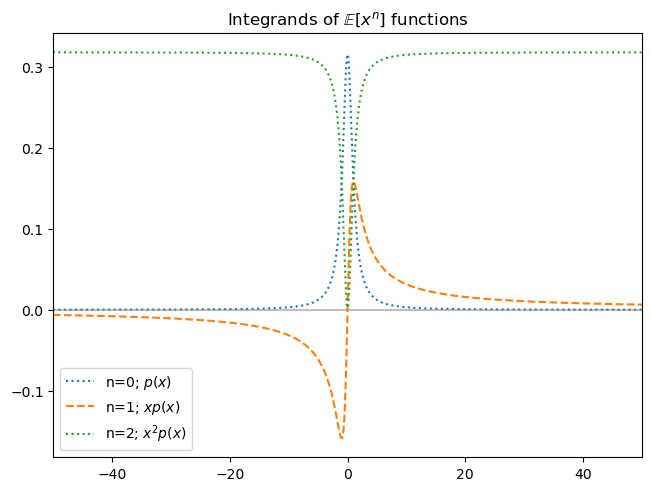

In [264]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

ax.plot(x_array, E_x0_integrand,linestyle='dotted', 
        label='n=0; $p(x)$')
ax.plot(x_array, E_x1_integrand, linestyle = 'dashed', 
        label = 'n=1; $xp(x)$')
ax.plot(x_array, E_x2_integrand, linestyle = 'dotted',
        label = 'n=2; $x^2 p(x)$')
ax.hlines(0,-50,50,color='gray',alpha=0.5)
ax.set_xlim(-50,50)
ax.legend()
ax.set_title('Integrands of $\mathbb{E}[x^n]$ functions')